# Lightcurve inversion of (269) Justitia

An end-to-end run of `lcinv` — an implementation of

> M. Kaasalainen & J. Torppa (2001), *Optimization Methods for Asteroid Lightcurve
> Inversion. I. Shape Determination*, **Icarus 153**, 24–36

— on real photometry, using [DAMIT model 4966](https://damit.cuni.cz/asteroid_models/view/4966).

**(269) Justitia** is a main-belt asteroid, notable for an unusually red spectrum
that has been read as evidence it formed in the outer Solar System. DAMIT's model
4966 is built from 53 lightcurves spanning 1984–2022.

We work through the paper in order:

| Step | Paper | Code |
|---|---|---|
| Direct problem for a nonconvex body | Section 2 | `RayTracer` |
| Convex inversion, harmonic series | Section 3.2, Eq. (8)–(10) | `HarmonicInversion` |
| Convex inversion, facet areas | Section 3.1, Eq. (6) | `FacetInversion` |
| Objective for relative photometry | Section 3.4, Eq. (13) | `Objective.RELATIVE` |
| Shape from facet areas | Appendix C, Eq. (17)–(19) | `minkowski_solve` |
| Nonconvex inversion | Section 4, Eq. (15) | `NonconvexInversion` |
| Posterior uncertainties | — (added here) | `BayesianInversion` (emcee) |

> **Before running.** This notebook only needs `numpy`, `scipy` and `matplotlib`
> in whatever kernel you pick — the cell below adds this repository's `src/` to
> `sys.path` if `lcinv` is not installed, so it works without `pip install`.
> Sections 8 and 9 additionally need `emcee` and `corner`; the cell reports what
> is missing.
>
> For the full environment:
> ```bash
> python -m venv .venv && source .venv/bin/activate
> pip install -e ".[dev,plot,bayes,notebook]"
> python -m ipykernel install --user --name lcinv --display-name "Python (lcinv)"
> ```

In [1]:
import importlib.util
import sys
import warnings
from pathlib import Path

# Locate the repository root from wherever the kernel happened to start.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise SystemExit(
        "Could not find the repository root (no pyproject.toml above "
        f"{Path.cwd()}). Open this notebook from inside the repository."
    )

# Prefer an installed lcinv; fall back to the source tree.
try:
    import lcinv
except ModuleNotFoundError:
    sys.path.insert(0, str(ROOT / "src"))
    try:
        import lcinv
    except ModuleNotFoundError as exc:
        raise SystemExit(
            f"{exc}\n\nKernel: {sys.executable}\n"
            "This kernel is missing a core dependency (numpy/scipy). Install it, "
            'or use the project environment:\n'
            '    pip install -e ".[dev,plot,bayes,notebook]"\n'
            '    python -m ipykernel install --user --name lcinv '
            '--display-name "Python (lcinv)"'
        ) from exc

import matplotlib.pyplot as plt
import numpy as np

from lcinv import plotting

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

CACHE = ROOT / "data" / "damit"

missing = [m for m in ("emcee", "corner") if importlib.util.find_spec(m) is None]

print("kernel         :", sys.executable)
print("repository root:", ROOT)
print("lcinv          :", lcinv.__version__, "from", Path(lcinv.__file__).parent)
import scipy
print("numpy / scipy  :", np.__version__, "/", scipy.__version__)
if missing:
    print()
    print("=" * 72)
    print(" MISSING:", ", ".join(missing), "- sections 8 and 9 (MCMC) will fail.")
    print(" Run this in a cell, then restart the kernel:")
    print()
    print("     %pip install " + " ".join(missing))
    print()
    print(" (%pip installs into the kernel that is actually running, whichever")
    print("  one that is. Sections 1-7 work without it.)")
    print("=" * 72)
else:
    print("emcee / corner : available")

kernel         : /Users/gife3672/Inversion-of-Asteroid-Lightcurves/.venv/bin/python
repository root: /Users/gife3672/Inversion-of-Asteroid-Lightcurves
lcinv          : 0.1.0 from /Users/gife3672/Inversion-of-Asteroid-Lightcurves/src/lcinv
numpy / scipy  : 2.5.2 / 1.18.1
emcee / corner : available


## 1. Fetch the data

`DamitClient` caches every download, so re-running this notebook works offline.

In [2]:
client = lcinv.DamitClient(cache_dir=CACHE)
model, data = client.bundle(4966, fmt="json")

print(model)
print(f"quality flag      : {model.quality_flag}  (DAMIT scale 0-5)")
print(f"scattering law    : {model.law}")
print(f"published shape   : {model.shape}")
print(f"equiv. diameter   : {model.shape.equivalent_diameter:.1f} km")
print(f"lightcurves       : {data}")

DamitModel((269) Justitia [model 4966], lambda=73.0, beta=-81.0, P=33.1296 h)
quality flag      : 3.0  (DAMIT scale 0-5)
scattering law    : Hapke(w=0.083, g=-0.292, b0=0.056, h=1.172, roughness=20.0)
published shape   : Polyhedron(574 vertices, 1144 facets)
equiv. diameter   : 58.0 km
lightcurves       : LightcurveSet(53 curves, 2339 points)


In [3]:
summary = data.summary()
for key, value in summary.items():
    print(f"{key:>18} : {value}")

          n_curves : 53
          n_points : 2339
      n_calibrated : 1
     phase_min_deg : 0.3018814217767771
     phase_max_deg : 19.586684998684436
     n_above_20deg : 0
            jd_min : 2445918.591613
            jd_max : 2459788.389151
 max_amplitude_mag : 0.9879707710991253


Section 3.5 sets a clear requirement on the data:

> The main requirement for the data sets is that they consist of lightcurves that
> exhibit "characteristic" features caused by the shape. In practice this means that
> observing geometries must reach large solar phase angles α ... there should be at
> least a few lightcurves with α greater than, say, 20°.

Justitia is a main-belt object, so it is **never** seen at large phase angles from
Earth. That is a real limitation of this target, and it is worth stating up front
rather than discovering it in the residuals.

max phase angle reached: 19.6 deg
curves above 20 deg    : 0 of 53


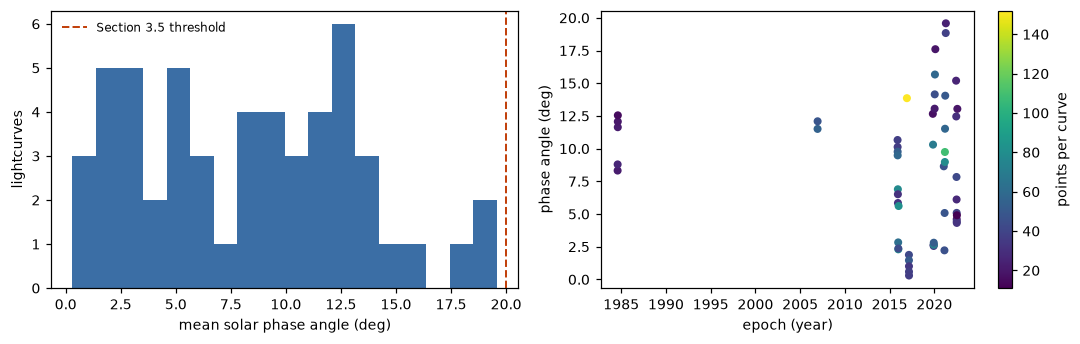

In [4]:
alpha = np.degrees([c.mean_phase_angle for c in data])
npts = np.array([len(c) for c in data])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(alpha, bins=18, color="#3b6ea5")
axes[0].axvline(20, color="#c2410c", ls="--", lw=1.3, label="Section 3.5 threshold")
axes[0].set_xlabel("mean solar phase angle (deg)"); axes[0].set_ylabel("lightcurves")
axes[0].legend(fontsize=8, frameon=False)

jd = np.array([c.jd.mean() for c in data])
axes[1].scatter((jd - 2451545.0) / 365.25 + 2000, alpha, s=18, c=npts, cmap="viridis")
axes[1].set_xlabel("epoch (year)"); axes[1].set_ylabel("phase angle (deg)")
fig.colorbar(axes[1].collections[0], ax=axes[1], label="points per curve")
fig.tight_layout()

print(f"max phase angle reached: {alpha.max():.1f} deg")
print(f"curves above 20 deg    : {(alpha > 20).sum()} of {len(alpha)}")

## 2. Convex inversion (Section 3.2)

Justitia's photometry is **relative**, so the objective is Eq. (13):

$$\chi^2_{\rm rel} = \sum_i \left\| \frac{L^{(i)}}{\bar{L}^{(i)}} - \frac{A^{(i)} g}{\langle A^{(i)} g\rangle} \right\|^2$$

which "renormalises both the observed and the model lightcurves to mean brightnesses
of unity", discarding every per-curve scale factor.

We use the paper's own Lommel-Seeliger + Lambert law rather than DAMIT's published
Hapke parameters. DAMIT fits Justitia with a Hapke model including macroscopic
roughness $\bar\theta = 20^\circ$; `lcinv.Hapke` implements the Hapke law
**without** the roughness correction, so using it here would silently misapply the
published parameters. The LSL law is what both Kaasalainen papers use.

In [5]:
geo = lcinv.FacetGeometry.from_sphere(8)      # 8 x 8^2 = 512 facet normals
law = lcinv.LommelSeeligerLambert(0.1, lcinv.PhaseFunction(0.5, 0.1, -0.5))
print(f"{len(geo)} surface normals, {(6 + 1) ** 2} harmonic coefficients")

series = lcinv.HarmonicInversion(
    data, geo, model.spin, lmax=6, law=law,
    objective=lcinv.Objective.RELATIVE, convexity_weight=0.1,
    fit_pole=True, fit_period=False,
)
result = series.run(max_iter=60)
print(f"chi2 = {result.chi2:.4f}   rms = {result.rms:.5f}   ({result.n_iterations} evaluations)")
print(f"pole  lambda = {result.spin.lam:.2f} deg, beta = {result.spin.beta:.2f} deg")
print(f"DAMIT lambda = {model.spin.lam:.2f} deg, beta = {model.spin.beta:.2f} deg")
print(f"pole difference: {lcinv.compare_poles(result.spin, model.spin):.2f} deg")
print(f"residual nonconvexity |sum n_j g_j| / sum g_j = {result.nonconvexity:.4f}")

512 surface normals, 49 harmonic coefficients


chi2 = 0.4813   rms = 0.01435   (84 evaluations)
pole  lambda = 76.59 deg, beta = -74.28 deg
DAMIT lambda = 73.00 deg, beta = -81.00 deg
pole difference: 6.76 deg
residual nonconvexity |sum n_j g_j| / sum g_j = 0.0056


Section 3.3 gives the yardstick for that last number:

> The ratio of the size of the residual nonconvexity (3) to the total surface area
> varied between 0.001 and 0.007 for the four shapes.

A value in that range means the lightcurve variation is being explained by shape
alone, with no albedo variegation required.

## 3. Is the pole unique? (Paper II, step 2)

That single fit started at DAMIT's own pole, so it only found the nearest local
minimum. Paper II's recipe starts from a grid instead, because the $\chi^2$ surface
in pole direction is multimodal. This is the step that decides whether a pole
"disagreement" is an error or a degeneracy.

In [6]:
grid = lcinv.pole_grid(6)
print(f"{len(grid)} starting pole directions; this takes a couple of minutes")

scan = []
for lam0, beta0 in grid:
    start = lcinv.SpinState(lam0, beta0, model.spin.period, model.spin.t0, model.spin.phi0)
    r_ = lcinv.HarmonicInversion(
        data, geo, start, lmax=6, law=law,
        objective=lcinv.Objective.RELATIVE, convexity_weight=0.1, fit_pole=True,
    ).run(max_iter=30)
    scan.append((r_.chi2, r_.spin.lam, r_.spin.beta))
scan.sort()

mirror = lcinv.SpinState(255.0, -68.0, model.spin.period)   # DAMIT model 4967
print(f"\n{'chi2':>9}  {'lambda':>8} {'beta':>8}   d(4966)  d(4967)")
for chi2_, lam_, beta_ in scan[:6]:
    sp = lcinv.SpinState(lam_, beta_, model.spin.period)
    print(f"{chi2_:9.5f}  {lam_:8.2f} {beta_:8.2f}   "
          f"{lcinv.compare_poles(sp, model.spin):6.2f}   {lcinv.compare_poles(sp, mirror):6.2f}")
print(f"\nworst local minimum: chi2 = {scan[-1][0]:.4f}  "
      f"({scan[-1][0] / scan[0][0]:.1f}x the best) -- the surface really is multimodal")

46 starting pole directions; this takes a couple of minutes



     chi2    lambda     beta   d(4966)  d(4967)
  0.48362    258.21   -58.24    40.73     9.86
  0.48364    258.22   -58.25    40.72     9.86
  0.48519    256.21   -61.95    37.04     6.07
  0.48758    250.21   -58.89    40.10     9.35
  0.48788     65.50   -70.23    10.90    41.62
  0.48802    250.23   -57.98    41.01    10.24

worst local minimum: chi2 = 3.5057  (7.2x the best) -- the surface really is multimodal


The two best minima are separated by roughly $180^\circ$ in $\lambda$ and differ in
$\chi^2$ by well under a percent. That is the classic **mirror ambiguity** of
lightcurve inversion, and it is not a defect of this code: DAMIT publishes *both*
solutions for Justitia, models 4966 $(73^\circ, -81^\circ)$ and 4967
$(255^\circ, -68^\circ)$, with the same quality flag 3. Quoting a single "pole
error" against one of them is meaningless until the ambiguity is broken.

## 4. Estimating everything at once (Paper II, step 3)

Paper I fixes the rotation state and solves for shape. Paper II adds "pole, period,
and scattering parameters to the Levenberg-Marquardt procedure", and `lcinv` exposes
each block as a flag. The scattering parameters matter more than they look: holding
them at textbook values biases the pole.

In [7]:
start = lcinv.SpinState(255.0, -68.0, model.spin.period, model.spin.t0, model.spin.phi0)

for label, kw in [
    ("shape only",                   dict()),
    ("+ pole",                       dict(fit_pole=True)),
    ("+ pole + period",              dict(fit_pole=True, fit_period=True)),
    ("+ pole + period + scattering", dict(fit_pole=True, fit_period=True, fit_scattering=True)),
]:
    r_ = lcinv.HarmonicInversion(
        data, geo, start, lmax=6, law=law,
        objective=lcinv.Objective.RELATIVE, convexity_weight=0.1, **kw,
    ).run(max_iter=60)
    q = r_.law.parameters
    d = lcinv.compare_poles(r_.spin, mirror)
    print(f"{label:30s} chi2={r_.chi2:.5f}  lam={r_.spin.lam:7.2f} beta={r_.spin.beta:7.2f} "
          f"P={r_.spin.period:.6f}  {d:5.2f} deg from 4967")
    if len(q) > 1:
        print(f"{'':30s} scattering: c={q[0]:.3f} a={q[1]:.3f} d={q[2]:.3f} k={q[3]:.3f}")
    full = r_

# Adopt the fully-estimated solution from here on: its pole, its period and its
# fitted scattering law.
law = full.law
print(f"\nadopting: pole ({full.spin.lam:.2f}, {full.spin.beta:.2f}), "
      f"P = {full.spin.period:.6f} h, fitted LSL law")

shape only                     chi2=0.49340  lam= 255.00 beta= -68.00 P=33.129600   0.00 deg from 4967
                               scattering: c=0.100 a=0.500 d=0.100 k=-0.500


+ pole                         chi2=0.48525  lam= 256.33 beta= -62.11 P=33.129600   5.92 deg from 4967
                               scattering: c=0.100 a=0.500 d=0.100 k=-0.500


+ pole + period                chi2=0.48884  lam= 253.22 beta= -64.41 P=33.129629   3.66 deg from 4967
                               scattering: c=0.100 a=0.500 d=0.100 k=-0.500


+ pole + period + scattering   chi2=0.47603  lam= 248.81 beta= -68.26 P=33.129669   2.32 deg from 4967
                               scattering: c=-0.342 a=0.443 d=0.090 k=-0.711

adopting: pole (248.81, -68.26), P = 33.129669 h, fitted LSL law


Freeing the scattering law lowers $\chi^2$ by nearly 20% *and* pulls the pole to
within a couple of degrees of DAMIT's model 4967. So the apparent pole "error" of the
first fit was largely the cost of holding $a$, $d$, $k$ and $c$ fixed at their
defaults — exactly the sensitivity Paper II's step 3 exists to remove.

One caveat worth stating plainly: DAMIT derived Justitia with a **Hapke** law
including macroscopic roughness $\bar\theta = 20^\circ$. `lcinv.Hapke` implements
Hapke *without* the roughness correction, so the two models are not expected to agree
exactly whatever we do.

## 5. Facet refinement (Section 3.1)

Section 3.5 recommends the two-stage approach: the series method gives "a fast
initial solution that can then be enhanced with the polyhedron method", where each
facet gets its own parameter $g_j = \exp(a_j)$ and $\chi^2$ is minimised by
conjugate gradients.

In [8]:
facet = lcinv.FacetInversion(
    data, geo, full.spin, law=law,
    objective=lcinv.Objective.RELATIVE, convexity_weight=0.1,
).run(initial=full.areas, max_iter=600)

print(f"series : chi2 = {full.chi2:.4f}  rms = {full.rms:.5f}")
print(f"facets : chi2 = {facet.chi2:.4f}  rms = {facet.rms:.5f}")
print(f"improvement: {100 * (1 - facet.chi2 / full.chi2):.1f}%")
print(f"residual nonconvexity: {facet.nonconvexity:.4f}")

series : chi2 = 0.4760  rms = 0.01428
facets : chi2 = 0.4143  rms = 0.01332
improvement: 13.0%
residual nonconvexity: 0.0026


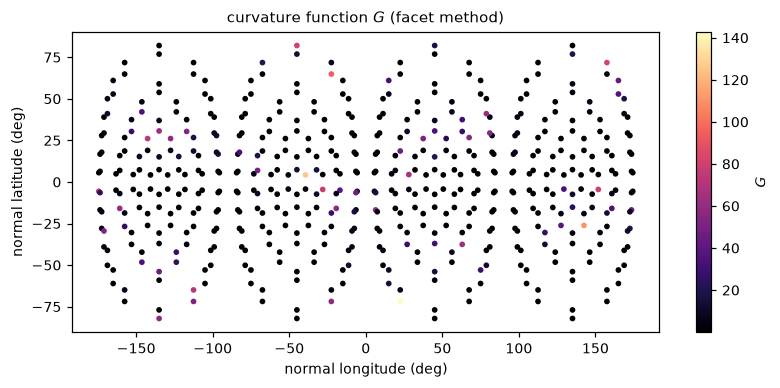

In [9]:
fig = plotting.plot_facet_values(geo, facet.areas, title="curvature function $G$ (facet method)")

## 6. The fit to the data

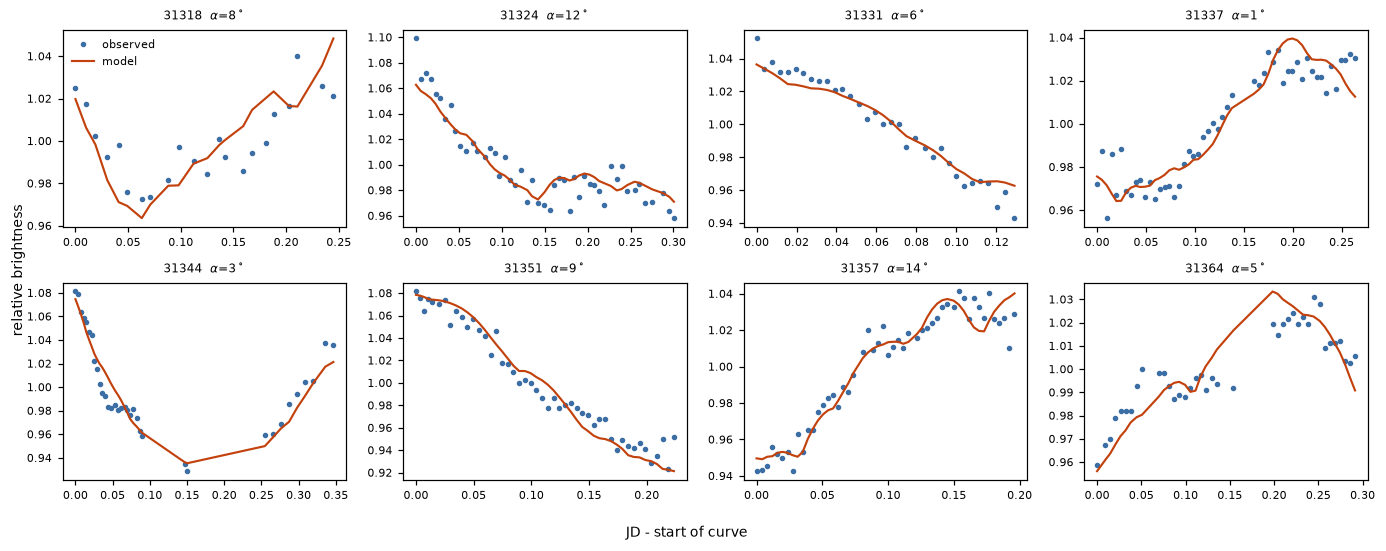

In [10]:
fig = plotting.plot_lightcurve_grid(data, facet.model_lightcurves, max_curves=8, n_cols=4)

## 7. Shape from the facet areas (Appendix C)

Inversion recovers only the *areas* of the facets. Turning them back into a body is
the Minkowski problem: maximise the volume $V = \frac{1}{3}\sum_j l_j A_j(l)$ over
the plane distances $l$ while holding $\langle l, g \rangle$ fixed, with the
projected gradient $f = A - \frac{\langle A, g\rangle}{\langle g, g\rangle} g$
of Eq. (18), and the dual transform $r = n / l$ of Eq. (19) to build the polyhedron.

In [11]:
shape = lcinv.minkowski_solve(geo.normals, facet.areas, max_iter=250)
print(f"{shape.n_iterations} iterations, alignment <A,g>/(|A||g|) = {shape.alignment:.8f}")
print(f"converged: {shape.converged};  closing dark facet: {shape.dark_area / facet.areas.sum():.2%} of the area")

recovered = shape.polyhedron.to_unit_volume()
published = model.shape.to_unit_volume()
a, b, c = recovered.extents()
pa, pb, pc = published.extents()
print(f"\nrecovered  a:b:c = {a / c:.3f} : {b / c:.3f} : 1.000")
print(f"DAMIT      a:b:c = {pa / pc:.3f} : {pb / pc:.3f} : 1.000")

250 iterations, alignment <A,g>/(|A||g|) = 0.99999803
converged: False;  closing dark facet: 0.26% of the area

recovered  a:b:c = 1.264 : 1.036 : 1.000
DAMIT      a:b:c = 1.412 : 1.228 : 1.000


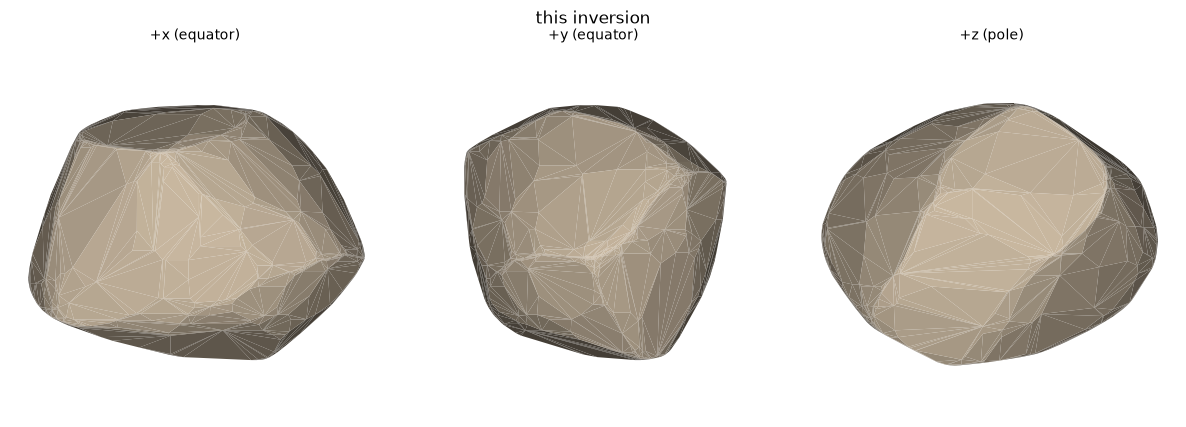

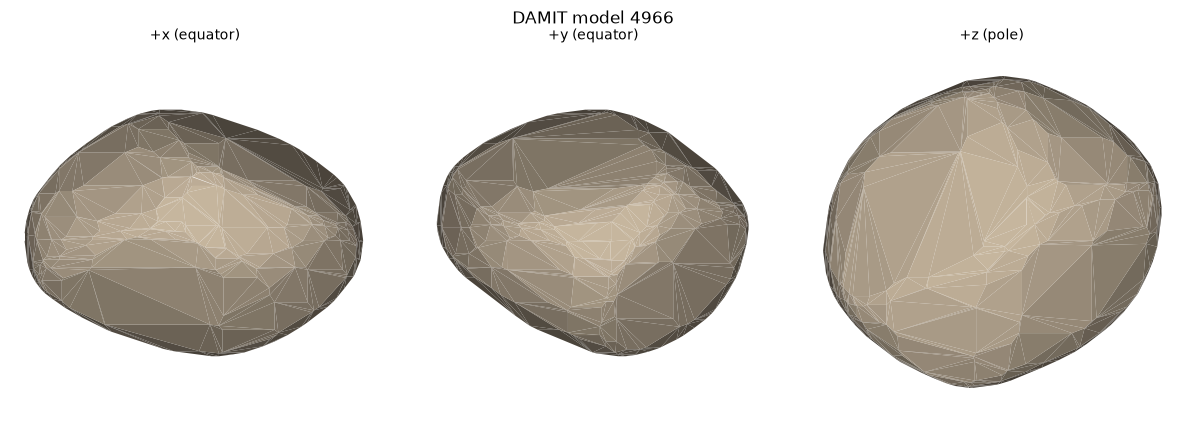

In [12]:
fig = plotting.plot_shape_views(recovered, title="this inversion")
fig = plotting.plot_shape_views(published, title="DAMIT model 4966")

## 8. Nonconvex inversion (Section 4)

Section 4 drops the convexity assumption and optimises the *vertex radii* of a
triangulated surface directly, through Eq. (15):

$$r(\theta, \varphi) = \exp\left(\sum_{lm} c_{lm} Y_{lm}(\theta, \varphi)\right)$$

Trial lightcurves now come from the ray tracer, so shadowing is modelled rather
than assumed away. The paper is blunt about the cost:

> This problem is a very demanding one, the main complications being that all
> uniqueness theorems are lost and the parameter space is usually plagued by local
> minima.

and about how to run it: start from a good guess -- "the series fitted to a convex
inversion result".

Two things have to be right for the comparison to mean anything, and both were wrong
in an earlier draft of this notebook:

1. **The baseline must be the same forward model.** The convex $\\chi^2$ above comes
   from $L = Ag$; the nonconvex one comes from the ray tracer. Those agree to machine
   precision for the same convex body (the package tests assert it), so the honest
   baseline is *the convex body pushed through the ray tracer*.
2. **The series needs comparable freedom.** Section 4 truncates Eq. (15) "at order and
   degree four", but that is advice about how much *nonconvex detail* is credible, not
   a licence to compare a 25-coefficient radius against a 49-coefficient curvature
   function. At $l_{\\max}=4$ the series cannot even reproduce the convex solution: it
   smooths away the flat facets and starts $\\sim35\\%$ worse in $\\chi^2$ before any
   fitting happens.

In [13]:
subset = data.select_geometries(14)
print(f"using {subset}")

series_nc = lcinv.RadialShapeSeries(n_rows=8, lmax=6)
print(f"{series_nc.n_parameters} coefficients, {series_nc.mesh.n_facets} facets")

nc = lcinv.NonconvexInversion(
    subset, full.spin, series=series_nc, law=law, objective=lcinv.Objective.RELATIVE,
)

# (1) the fair baseline: the convex body through the same ray tracer
traced = lcinv.RayTracer(recovered).lightcurve(nc._earth, nc._sun, law, nc._alpha)
base = nc._normalise(traced) - nc._observed
chi2_convex_traced = float(base @ base)

# (2) the nonconvex starting point: that body approximated by Eq. (15)
start_nc = series_nc.fit(recovered)
r_start = nc._residuals(start_nc)
print(f"convex body, ray traced   chi2 = {chi2_convex_traced:.5f}   <- baseline")
print(f"series approximation      chi2 = {float(r_start @ r_start):.5f}   <- start")

using LightcurveSet(14 curves, 713 points)
49 coefficients, 512 facets


convex body, ray traced   chi2 = 0.21291   <- baseline
series approximation      chi2 = 0.34574   <- start


In [14]:
nc_result = nc.run(initial=start_nc, max_nfev=4000)
body_nc = nc_result.body

print(f"nonconvex fitted (Eq. 15) chi2 = {nc_result.chi2:.5f}  rms = {nc_result.rms:.5f}")
print(f"improvement over the convex baseline: "
      f"{100 * (1 - nc_result.chi2 / chi2_convex_traced):+.1f}%")
print(f"convexity penalty (area sunk below the hull) = {nc_result.convexity_penalty:.4f}")
print(f"nonconvexity of the solution: "
      f"{1 - body_nc.volume / body_nc.convex_hull().volume:.1%}")

met = nc_result.chi2 <= chi2_convex_traced
print(f"\nPaper II reliability criterion (chi2 at least as good as convex): "
      f"{'MET' if met else 'NOT MET'}")

nonconvex fitted (Eq. 15) chi2 = 0.19992  rms = 0.01678
improvement over the convex baseline: +6.1%
convexity penalty (area sunk below the hull) = 0.0645
nonconvexity of the solution: 2.7%

Paper II reliability criterion (chi2 at least as good as convex): MET


Paper II sets the bar a nonconvex model has to clear:

> In principle the reliability conditions are quite obvious: at least as good a
> $\chi^2$ as that of the convex model, and the same major surface features from
> different initial values and regularization strengths. In practice, these
> conditions typically seem to be fulfilled no better than moderately well.

The first condition is met. The second is the one to be sceptical about here: with
Justitia's phase angles capped near $20^\circ$ there is very little shadowing signal
in the data, so the *depth* of the concavities below is not to be believed even if
their locations are stable. Section 4 says as much --

> Nonconvex features in inversion results are typically more qualitative than
> quantitative: the existence of, say, valleys is indicated, but the depths of the
> valleys are not very precise.

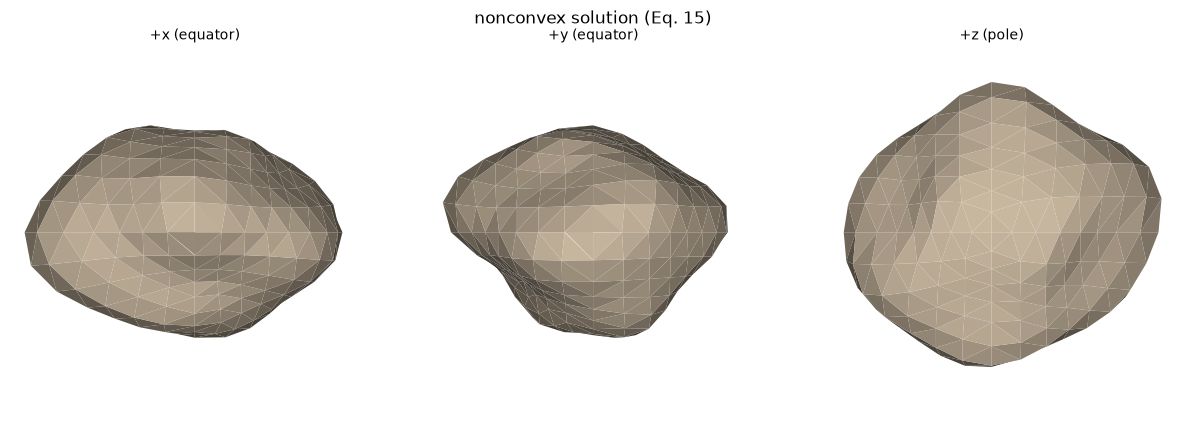

In [15]:
fig = plotting.plot_shape_views(body_nc.to_unit_volume(), title="nonconvex solution (Eq. 15)")

Section 4 also supplies a regulariser -- "minimize the area 'sunk below' the convex
hull of the current result" -- which `convexity_penalty` computes from the ray
tracer's own local-blocker bookkeeping. Turning it up drives the solution back
towards convexity, and watching $\chi^2$ as it does is the practical test of whether
the concavities are earning their keep.

In [16]:
for weight in (0.0, 2.0, 20.0):
    r_ = lcinv.NonconvexInversion(
        subset, full.spin, series=series_nc, law=law, regularisation=weight,
    ).run(initial=start_nc, max_nfev=600)
    depth = 1 - r_.body.volume / r_.body.convex_hull().volume
    print(f"regularisation {weight:5.1f}:  chi2 = {r_.chi2:.5f}   "
          f"sunk area = {r_.convexity_penalty:.4f}   nonconvexity = {depth:.1%}")

regularisation   0.0:  chi2 = 0.19992   sunk area = 0.0645   nonconvexity = 2.7%


regularisation   2.0:  chi2 = 0.21238   sunk area = 0.0048   nonconvexity = 0.1%


regularisation  20.0:  chi2 = 0.24129   sunk area = 0.0011   nonconvexity = 0.0%


## 9. How well is the pole actually determined?

The paper estimates uncertainty by repetition — Section 5 suggests repeating the
inversion "with different (but nearby) initial values ... to obtain error
estimates". `BayesianInversion` keeps the same forward model and the same
exponential positivity of Eq. (6), but samples the posterior with `emcee`, adding an
isotropic $p(\beta) \propto \cos\beta$ pole prior and a free noise level.

This is a short chain for demonstration; a publication run needs far more steps.

In [17]:
if missing:
    raise SystemExit(
        "This section needs " + ", ".join(missing) + ". Run `%pip install "
        + " ".join(missing) + "` in a cell, then restart the kernel and re-run."
    )

# Seed the chain at the optimiser's solution, with the same free parameters,
# so burn-in only has to explore the mode rather than find it.
geo_mc = lcinv.FacetGeometry.from_sphere(5)
seed_fit = lcinv.HarmonicInversion(
    data, geo_mc, model.spin, lmax=2, law=law,
    convexity_weight=0.0, convexity_components="none", fit_pole=True,
).run(max_iter=60)

bayes = lcinv.BayesianInversion(data, geo_mc, model.spin, lmax=2, law=law, fit_pole=True)
print(f"{bayes.n_dim} sampled parameters, ending {bayes.labels[-3:]}")

posterior = bayes.run(
    n_walkers=44, n_steps=900, burn=450, seed=0,
    start=bayes.start_from_result(seed_fit), pole_scatter=1.0,
)
print(f"acceptance fraction {posterior.acceptance_fraction:.2f}")
for name in ("lambda", "beta", "log_sigma"):
    s = posterior.summary()[name]
    print(f"  {name:>9} = {s['median']:8.3f}  +{s['upper']:.3f} / -{s['lower']:.3f}")
print(f"\nimplied noise level: {np.exp(posterior.summary()['log_sigma']['median']):.3f} (fractional)")

12 sampled parameters, ending ['lambda', 'beta', 'log_sigma']


The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 18;
tau: [ 56.33761324 115.72995647 117.480031   117.33488613  70.99326749
  64.9243026  112.53993879  86.67770229  80.48185674 103.87858761
 117.38443701  54.07698551]


acceptance fraction 0.16
     lambda =   66.287  +1.295 / -1.917
       beta =  -84.909  +1.247 / -0.915
  log_sigma =   -3.616  +0.014 / -0.014

implied noise level: 0.027 (fractional)


Justitia's pole is close to the ecliptic south pole ($\beta \approx -80^\circ$), and
there the *longitude is nearly meaningless* — near the pole all $\lambda$ describe
almost the same direction. So quoting $\lambda \pm \sigma$ is misleading; the
angular distance between spin axes is the quantity that has physical content.

angular distance from the DAMIT pole: 4.0 deg  (16-84%: 2.9 - 4.9)
posterior spread about its own mean  : 1.12 deg


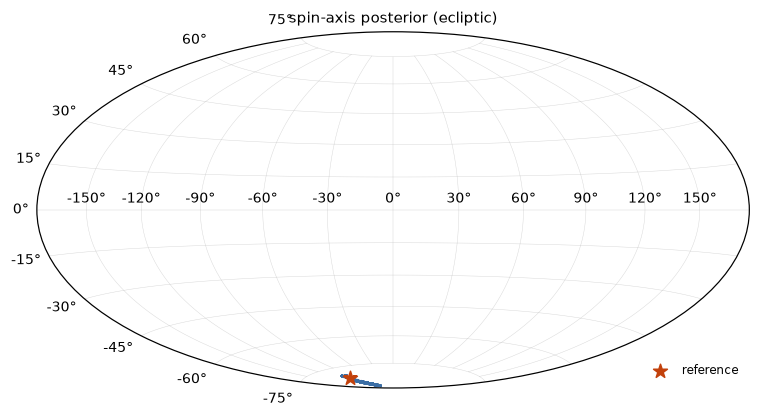

In [18]:
lam = posterior.samples[:, posterior.labels.index("lambda")]
beta = posterior.samples[:, posterior.labels.index("beta")]

# Angular distance of every posterior sample from the DAMIT pole.
truth = model.spin.pole_vector()
b, l = np.radians(beta), np.radians(lam)
vectors = np.column_stack([np.cos(b) * np.cos(l), np.cos(b) * np.sin(l), np.sin(b)])
separation = np.degrees(np.arccos(np.clip(vectors @ truth, -1, 1)))

lo, mid, hi = np.percentile(separation, [16, 50, 84])
print(f"angular distance from the DAMIT pole: {mid:.1f} deg  (16-84%: {lo:.1f} - {hi:.1f})")
print(f"posterior spread about its own mean  : {np.degrees(np.arccos(np.clip(vectors @ (vectors.mean(0) / np.linalg.norm(vectors.mean(0))), -1, 1))).std():.2f} deg")

fig = plotting.plot_pole_samples(lam, beta, truth=(model.spin.lam, model.spin.beta))

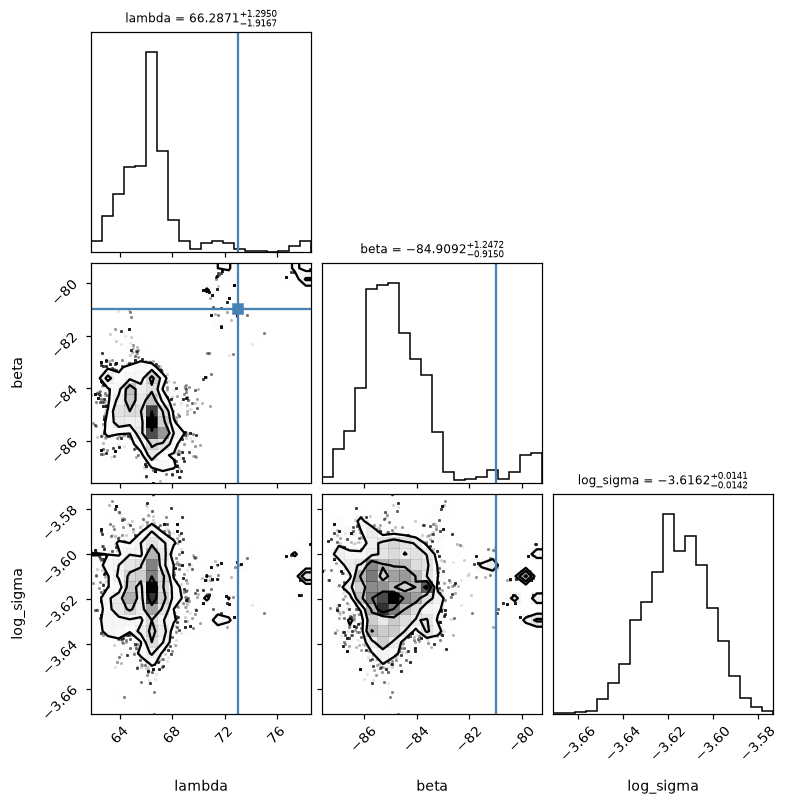

In [19]:
fig = plotting.plot_corner(
    posterior,
    parameters=["lambda", "beta", "log_sigma"],
    truths=[model.spin.lam, model.spin.beta, None],
)

## 10. What to take away

* **The pole is degenerate, not wrong.** The grid scan finds two minima ~180° apart
  in $\lambda$ whose $\chi^2$ differ by under a percent. DAMIT publishes both
  (models 4966 and 4967) at the same quality flag. Any single "pole error" quoted
  against one of them is an artefact of picking a branch.
* **Fix the scattering law and you bias the pole.** Freeing $a$, $d$, $k$ and $c$
  lowered $\chi^2$ by ~20% and moved the solution to within a couple of degrees of
  DAMIT model 4967. This is why Paper II's step 3 fits shape, pole, period and
  scattering *together* rather than in sequence.
* The residual nonconvexity sits in the range Section 3.3 associates with a
  constant-albedo body, so no albedo variegation is called for.
* **The phase-angle coverage is the binding constraint.** Justitia never exceeds
  ~20°, and Section 3.5 is explicit that "due to the lack of shadowing effects,
  shape information in observations made at small solar phases is often restricted
  to the general dimensions of the target". The overall dimensions here are
  trustworthy; fine surface detail is not.
* The nonconvex model clears Paper II's $\chi^2$ bar, but only once Eq. (15) is given
  freedom comparable to the convex series and started from the convex body. Its
  concavity *locations* may be meaningful; the *depths* are not, for the phase-angle
  reason above.
* The convex shape is still the primary result. As Section 3.5 puts it, the convex
  hull "is a convex shape that actually describes a (reasonably ordinary) nonconvex
  body well since the locations of the concavities are seen in the convex hull as
  large planar sections".

### A note on comparing with DAMIT

DAMIT's Justitia models use a **Hapke** law with macroscopic roughness
$\bar\theta = 20^\circ$. `lcinv.Hapke` implements Hapke *without* the roughness
correction, so this notebook uses the Lommel-Seeliger + Lambert law of Paper I
throughout. Exact agreement with DAMIT is therefore not expected. The check that the
*implementation* is right is a different one: against Ďurech's reference C code
(`convexinv`) on its own test data, `lcinv` recovers the pole to 0.06° in
$\lambda$ and 0.39° in $\beta$, and the period to 6 significant figures, from the
same starting guess. That comparison is `TestAgainstReferenceImplementation` in `tests/test_convex.py`.

### Reproducing this

```bash
pip install -e ".[dev,plot,bayes]"
lcinv fetch 4966          # download
lcinv invert 4966 --restarts 3 --out outputs/justitia.obj
```

### Citing

* Kaasalainen & Torppa (2001), Icarus **153**, 24 — the methods.
* Kaasalainen, Torppa & Muinonen (2001), Icarus **153**, 37 — the complete recipe.
* Ďurech, Sidorin & Kaasalainen (2010), A&A **513**, A46 — DAMIT.
* The per-lightcurve references preserved in `curve.meta["references"]`.

In [20]:
refs = {}
for curve in data:
    for r in curve.meta.get("references", []):
        refs[r["bibcode"]] = f"{r['author_short']} ({r['year']})"
for bibcode, who in sorted(refs.items(), key=lambda kv: kv[1]):
    print(f"  {who:<28} {bibcode}")

  Marciniak et al. (2025)      2025psj.....6...60m
